+# Hidden Markov Models for Human Activity Recognition
### Formative 2  

**Activities:** Still | Standing | Walking | Jumping  
**Sensors:** Accelerometer (ax, ay, az) + Gyroscope (gx, gy, gz)  
**Model:** Gaussian HMM trained with Baum–Welch, decoded with Viterbi

In [8]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "hmmlearn"])

0

In [ ]:
# Unzip & Merge Sensor Logger recordings → data folders


import os, zipfile, pandas as pd

ZIP_DIR  = './zips'    
DATA_DIR = './data'
ACTIVITIES = ['still', 'standing', 'walking', 'jumping']

for act in ACTIVITIES:
    os.makedirs(os.path.join(DATA_DIR, act), exist_ok=True)

processed, skipped = 0, 0

for fname in sorted(os.listdir(ZIP_DIR)):
    if not fname.endswith('.zip'):
        continue

    activity = next((a for a in ACTIVITIES if fname.lower().startswith(a)), None)
    if activity is None:
        print(f"[SKIP] Can't infer activity: {fname}"); skipped += 1; continue

    try:
        with zipfile.ZipFile(os.path.join(ZIP_DIR, fname), 'r') as z:
            with z.open('Accelerometer.csv') as f:
                acc = pd.read_csv(f).rename(columns={'x':'ax','y':'ay','z':'az'})
            acc = acc[['time','seconds_elapsed','ax','ay','az']]

            if 'Gyroscope.csv' in z.namelist():
                with z.open('Gyroscope.csv') as f:
                    gyr = pd.read_csv(f).rename(columns={'x':'gx','y':'gy','z':'gz'})
                gyr = gyr[['time','gx','gy','gz']]
                merged = pd.merge_asof(acc.sort_values('time'), gyr.sort_values('time'),
                                       on='time', direction='nearest')
            else:
                merged = acc.copy()
                merged[['gx','gy','gz']] = 0.0

            out_path = os.path.join(DATA_DIR, activity, fname.replace('.zip', '.csv'))
            merged.to_csv(out_path, index=False)
            print(f"✓ {fname} → data/{activity}/  ({len(merged)} rows)")
            processed += 1

    except Exception as e:
        print(f"[ERROR] {fname}: {e}"); skipped += 1

print(f"\nDone — {processed} processed, {skipped} skipped.")
for act in ACTIVITIES:
    n = len([f for f in os.listdir(os.path.join(DATA_DIR, act)) if f.endswith('.csv')])
    print(f"  {act:10s}: {n} files")

✓ Jumping-2026-07-04_20-29-58.zip → data/jumping/  (1507 rows)
✓ Jumping-2026-07-04_20-30-14.zip → data/jumping/  (1441 rows)
✓ jumping-2026-07-04_20-28-05.zip → data/jumping/  (1339 rows)
✓ jumping-2026-07-04_20-28-51.zip → data/jumping/  (1424 rows)
✓ jumping-2026-07-04_20-29-08.zip → data/jumping/  (1590 rows)
✓ jumping-2026-07-04_20-29-25.zip → data/jumping/  (1635 rows)
✓ jumping-2026-07-04_20-29-43.zip → data/jumping/  (1355 rows)
✓ jumping-2026-07-04_22-03-07.zip → data/jumping/  (1219 rows)
✓ jumping-2026-07-04_22-03-20.zip → data/jumping/  (1145 rows)
✓ jumping-2026-07-04_22-03-33.zip → data/jumping/  (1239 rows)
✓ jumping-2026-07-04_22-04-59.zip → data/jumping/  (1292 rows)
✓ jumping-2026-07-04_22-08-01.zip → data/jumping/  (1213 rows)
✓ jumping-2026-07-04_22-08-14.zip → data/jumping/  (1274 rows)
✓ jumping-2026-07-04_22-08-28.zip → data/jumping/  (1201 rows)
✓ jumping-2026-07-04_22-08-41.zip → data/jumping/  (1211 rows)
✓ jumping-2026-07-04_22-08-54.zip → data/jumping/  (120

---
## 0. Imports & Global Config

In [ ]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.signal import resample as scipy_resample

from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
np.random.seed(42)

# ── global constants (EDIT THESE to match your setup) ─────────────────────────
ACTIVITIES      = ['still', 'standing', 'walking', 'jumping']
N_STATES        = len(ACTIVITIES)          # 4 hidden states
TARGET_SR       = 100                      # Hz — harmonised sampling rate
WINDOW_SIZE     = TARGET_SR * 1            # 1-second window = 100 samples
STEP_SIZE       = WINDOW_SIZE // 2         # 50% overlap → 50 samples
DATA_DIR        = './data'                 # root folder containing activity sub-folders
SENSOR_COLS     = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

print(f"Window size : {WINDOW_SIZE} samples  ({WINDOW_SIZE/TARGET_SR:.1f} s)")
print(f"Step size   : {STEP_SIZE} samples  (50% overlap)")
print(f"Activities  : {ACTIVITIES}")
print("Imports OK ✓")

Window size : 100 samples  (1.0 s)
Step size   : 50 samples  (50% overlap)
Activities  : ['still', 'standing', 'walking', 'jumping']
Imports OK ✓


---
## Data Loading

** my folder structure:**
```
data/
  still/      still_p1_01.csv, still_p2_01.csv, ...
  standing/   standing_p1_01.csv, ...
  walking/    walking_p1_01.csv, ...
  jumping/    jumping_p1_01.csv, ...
```

Each CSV must have columns: `timestamp, ax, ay, az, gx, gy, gz`  




In [ ]:
RENAME_MAP = {
    'accelerometerAccelerationX(G)' : 'ax',
    'accelerometerAccelerationY(G)' : 'ay',
    'accelerometerAccelerationZ(G)' : 'az',
    'gyroRotationX(rad/s)'          : 'gx',
    'gyroRotationY(rad/s)'          : 'gy',
    'gyroRotationZ(rad/s)'          : 'gz',
    'x'  : 'ax', 'y'  : 'ay', 'z'  : 'az',
    'wx' : 'gx', 'wy' : 'gy', 'wz' : 'gz',
}

MEMBER_SAMPLE_RATES = {
    'p1': 100,   
    'p2': 100,   
}


def load_csv(filepath: str, member_sr: int = TARGET_SR) -> np.ndarray | None:
    """Load one sensor CSV, rename columns, resample to TARGET_SR, return ndarray."""
    try:
        df = pd.read_csv(filepath)
        df.rename(columns=RENAME_MAP, inplace=True)

        # keep only sensor columns that exist
        available = [c for c in SENSOR_COLS if c in df.columns]
        if len(available) < 3:
            print(f"  [SKIP] {filepath} — missing sensor columns")
            return None

        # fill any missing gyro with zeros 
        for col in SENSOR_COLS:
            if col not in df.columns:
                df[col] = 0.0

        data = df[SENSOR_COLS].dropna().values.astype(float)

        # resample if SR differs from target SR
        if member_sr != TARGET_SR:
            n_target = int(len(data) * TARGET_SR / member_sr)
            data = scipy_resample(data, n_target)

        return data

    except Exception as e:
        print(f"  [ERROR] {filepath}: {e}")
        return None


def load_all_data(data_dir: str) -> tuple[list, list, list]:
    """Walk data_dir/activity/ folders and load every CSV file."""
    signals, labels, file_paths = [], [], []

    for label_idx, activity in enumerate(ACTIVITIES):
        act_dir = os.path.join(data_dir, activity)
        if not os.path.isdir(act_dir):
            print(f"[WARNING] Folder not found: {act_dir}")
            continue

        files = sorted(glob.glob(os.path.join(act_dir, '*.csv')))
        print(f"\n{activity.upper():10s} → {len(files)} files found")

        for fp in files:
            # infer member tag from filename (e.g. 'walking_p1_03.csv' → 'p1')
            fname = os.path.basename(fp)
            member = next(
                (k for k in MEMBER_SAMPLE_RATES if k in fname),
                list(MEMBER_SAMPLE_RATES.keys())[0]
            )
            sr = MEMBER_SAMPLE_RATES[member]

            arr = load_csv(fp, member_sr=sr)
            if arr is not None and len(arr) >= WINDOW_SIZE:
                signals.append(arr)
                labels.append(label_idx)
                file_paths.append(fp)
                print(f"  ✓ {fname:40s}  shape={arr.shape}  SR={sr}Hz")

    print(f"\nTotal files loaded: {len(signals)}")
    return signals, labels, file_paths


signals, file_labels, file_paths = load_all_data(DATA_DIR)

#summary table
summary = {act: 0 for act in ACTIVITIES}
for lbl in file_labels:
    summary[ACTIVITIES[lbl]] += 1
print("\nFile counts per activity:")
for act, cnt in summary.items():
    print(f"  {act:10s}: {cnt} files")


STILL      → 50 files found
  ✓ still-2026-07-04_20-38-12.csv             shape=(1170, 6)  SR=100Hz
  ✓ still-2026-07-04_20-38-25.csv             shape=(1093, 6)  SR=100Hz
  ✓ still-2026-07-04_20-38-37.csv             shape=(1792, 6)  SR=100Hz
  ✓ still-2026-07-04_20-38-59.csv             shape=(1106, 6)  SR=100Hz
  ✓ still-2026-07-04_20-39-14.csv             shape=(1462, 6)  SR=100Hz
  ✓ still-2026-07-04_20-39-29.csv             shape=(1255, 6)  SR=100Hz
  ✓ still-2026-07-04_20-39-47.csv             shape=(1192, 6)  SR=100Hz
  ✓ still-2026-07-04_20-40-04.csv             shape=(1077, 6)  SR=100Hz
  ✓ still-2026-07-04_21-28-54.csv             shape=(10508, 6)  SR=100Hz
  ✓ still-2026-07-04_22-52-45.csv             shape=(1963, 6)  SR=100Hz
  ✓ still-2026-07-04_22-53-05.csv             shape=(1281, 6)  SR=100Hz
  ✓ still-2026-07-04_22-53-19.csv             shape=(1894, 6)  SR=100Hz
  ✓ still-2026-07-04_22-53-39.csv             shape=(1206, 6)  SR=100Hz
  ✓ still-2026-07-04_22-53-52.csv 

In [ ]:
USE_SYNTHETIC = len(signals) == 0  

if USE_SYNTHETIC:
    print("⚠ No real data found — generating synthetic sensor signals for demonstration.")
    N_FILES_PER_ACTIVITY = 15
    SECONDS_PER_FILE     = 8     
    N_SAMPLES_PER_FILE   = TARGET_SR * SECONDS_PER_FILE

    def _make_synthetic(activity: str, n: int) -> np.ndarray:
        t = np.linspace(0, n / TARGET_SR, n)
        noise = lambda s: np.random.normal(0, s, n)

        if activity == 'still':
            ax = noise(0.02);  ay = noise(0.02);  az = noise(0.02)
            gx = noise(0.01);  gy = noise(0.01);  gz = noise(0.01)

        elif activity == 'standing':
            ax = noise(0.10);  ay = noise(0.10);  az = 9.8 + noise(0.10)
            gx = noise(0.05);  gy = noise(0.05);  gz = noise(0.05)

        elif activity == 'walking':
            f = 1.9 + np.random.uniform(-0.2, 0.2)  
            ax = 0.5 * np.sin(2*np.pi*f*t)    + noise(0.12)
            ay = 0.3 * np.sin(2*np.pi*f*t+1)  + noise(0.12)
            az = 9.8 + 0.8*np.sin(2*np.pi*f*t) + noise(0.15)
            gx = 0.4 * np.sin(2*np.pi*f*t)    + noise(0.08)
            gy = 0.2 * np.sin(2*np.pi*f*t+0.5)+ noise(0.08)
            gz = noise(0.05)

        else:  # jumping
            f = 1.0 + np.random.uniform(-0.1, 0.1)   
            ax = 0.3 * np.sin(2*np.pi*f*t)    + noise(0.25)
            ay = 0.3 * np.sin(2*np.pi*f*t)    + noise(0.25)
            az = 9.8 + 3.5*np.sin(2*np.pi*f*t) + noise(0.40)
            gx = 0.6 * np.sin(2*np.pi*f*t)    + noise(0.15)
            gy = 0.6 * np.sin(2*np.pi*f*t)    + noise(0.15)
            gz = noise(0.10)

        return np.column_stack([ax, ay, az, gx, gy, gz])

    signals, file_labels = [], []
    for label_idx, act in enumerate(ACTIVITIES):
        for _ in range(N_FILES_PER_ACTIVITY):
            arr = _make_synthetic(act, N_SAMPLES_PER_FILE)
            signals.append(arr)
            file_labels.append(label_idx)

    print(f"Synthetic dataset: {len(signals)} files, {N_FILES_PER_ACTIVITY} per activity.")
else:
    print(f"Using real data: {len(signals)} files loaded.")

Using real data: 202 files loaded.


---
## Visualise Raw Sensor Signals

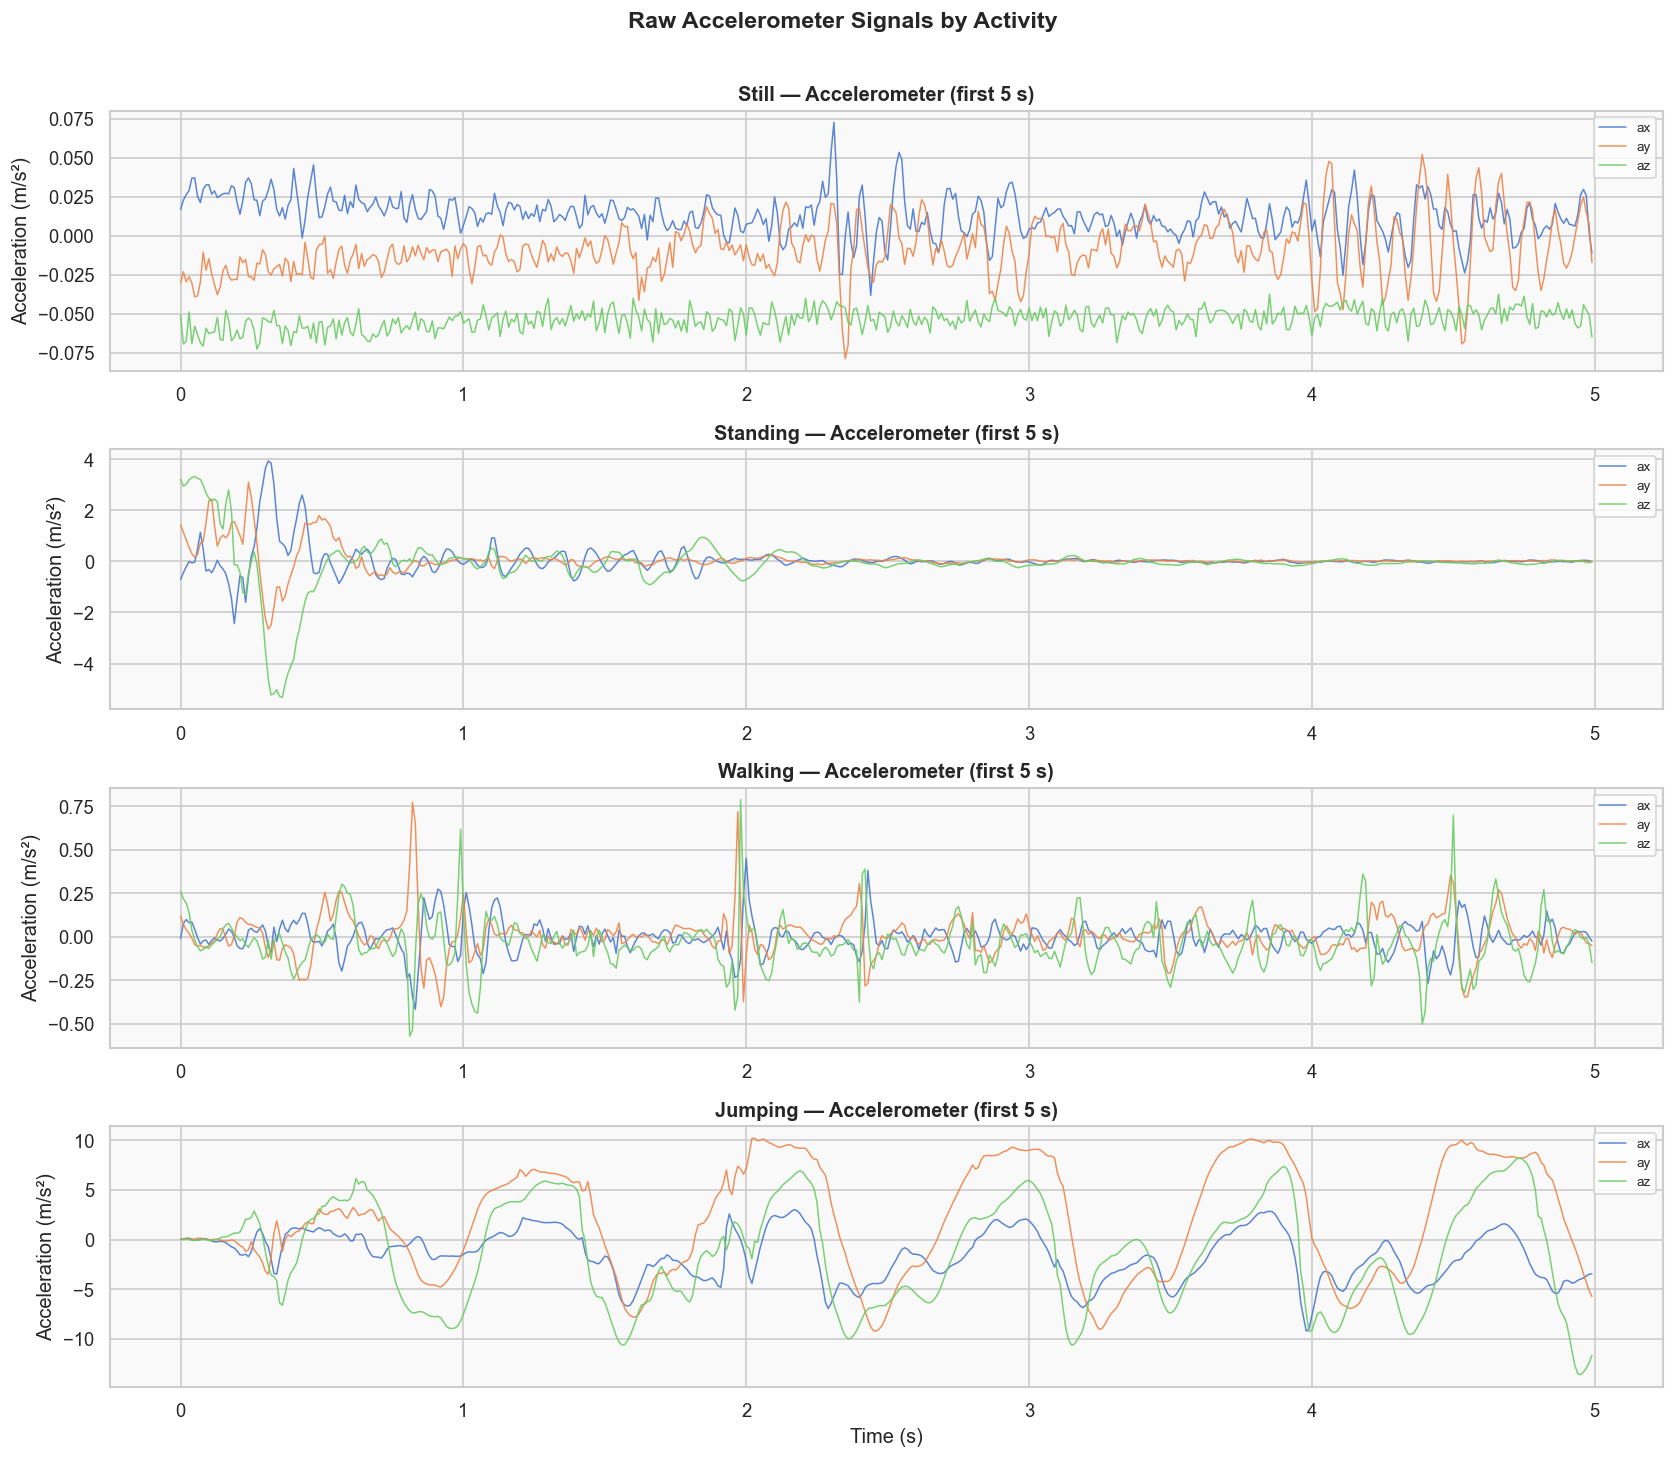

Figure saved: fig_raw_signals.png


In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (act, color) in enumerate(zip(ACTIVITIES, colors)):
    # find first file for this activity
    idx = next(j for j, lbl in enumerate(file_labels) if lbl == i)
    sig = signals[idx][:TARGET_SR*5]   # show first 5 seconds
    t   = np.arange(len(sig)) / TARGET_SR

    ax = axes[i]
    ax.plot(t, sig[:, 0], label='ax', linewidth=0.9, alpha=0.9)
    ax.plot(t, sig[:, 1], label='ay', linewidth=0.9, alpha=0.9)
    ax.plot(t, sig[:, 2], label='az', linewidth=0.9, alpha=0.9)
    ax.set_title(f'{act.capitalize()} — Accelerometer (first 5 s)', fontweight='bold')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_facecolor('#f9f9f9')

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw Accelerometer Signals by Activity', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_raw_signals.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_raw_signals.png")

---
## Feature Extraction

**Window size justification:**  
At `TARGET_SR = 100 Hz`, a 1-second window (100 samples) captures one full gait cycle (~0.5 s per step at 2 Hz walking cadence) and provides sufficient frequency resolution for FFT (1 Hz resolution). A 50% overlap (step = 50 samples) prevents losing transient events at window boundaries.

**Features extracted per window (24 total):**

| Domain | Feature | Axes | Count |
|---|---|---|---|
| Time | Mean | ax,ay,az,gx,gy,gz | 6 |
| Time | Std dev | ax,ay,az,gx,gy,gz | 6 |
| Time | RMS | ax,ay,az,gx,gy,gz | 6 |
| Time | SMA (acc only) | ax+ay+az | 1 |
| Frequency | Dominant frequency | ax,ay,az | 3 |
| Frequency | Spectral energy | ax,ay,az | 3 |

In [ ]:
FEATURE_NAMES = (
    [f'mean_{c}' for c in SENSOR_COLS] +
    [f'std_{c}'  for c in SENSOR_COLS] +
    [f'rms_{c}'  for c in SENSOR_COLS] +
    ['sma'] +
    [f'dom_freq_{c}' for c in ['ax','ay','az']] +
    [f'spec_energy_{c}' for c in ['ax','ay','az']]
)

assert len(FEATURE_NAMES) == 25, f"Expected 25 features, got {len(FEATURE_NAMES)}"
print(f"Total features: {len(FEATURE_NAMES)}")
print("Feature list:", FEATURE_NAMES)


def extract_features(window: np.ndarray) -> np.ndarray:
    """
    Extract 25 time- and frequency-domain features from a single window.

    Parameters
    ----------
    window : ndarray of shape (WINDOW_SIZE, 6) — [ax,ay,az,gx,gy,gz]

    Returns
    -------
    features : 1-D ndarray of length 25
    """
    feats = []

    #time domain: mean, std, RMS per axis 
    for i in range(6):
        s = window[:, i]
        feats.append(np.mean(s))                    # mean: captures average orientation/bias
        
    for i in range(6):
        s = window[:, i]
        feats.append(np.std(s))                     # std: captures variability (high for jumping)

    for i in range(6):
        s = window[:, i]
        feats.append(np.sqrt(np.mean(s**2)))        # RMS: total signal power

    #time domain: signal magnitude area (accelerometer only) 
    sma = np.sum(np.abs(window[:, :3])) / len(window)
    feats.append(sma)                               # SMA: distinguishes rest vs movement

    #frequency domain: dominant frequency + spectral energy (acc axes) 
    for i in range(3):
        s = window[:, i]
        freqs  = rfftfreq(len(s), d=1.0/TARGET_SR)  # frequency bins
        mag    = np.abs(rfft(s))                     # FFT magnitudes
        dom_f  = freqs[np.argmax(mag[1:]) + 1]      # skip DC (index 0)
        energy = np.sum(mag**2) / len(s)             # Parseval normalised
        feats.append(dom_f)    
        feats.append(energy)   

    return np.array(feats, dtype=float)


def sliding_window_features(
        signal: np.ndarray,
        label: int
) -> tuple[np.ndarray, np.ndarray]:
    """Slide a window over `signal` and return feature matrix + label array."""
    X, y = [], []
    for start in range(0, len(signal) - WINDOW_SIZE + 1, STEP_SIZE):
        w = signal[start : start + WINDOW_SIZE]
        X.append(extract_features(w))
        y.append(label)
    return np.array(X), np.array(y)


X_list, y_list = [], []
for sig, lbl in zip(signals, file_labels):
    Xw, yw = sliding_window_features(sig, lbl)
    X_list.append(Xw)
    y_list.append(yw)

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)

print(f"\nFeature matrix : {X_all.shape}  ({X_all.shape[0]} windows × {X_all.shape[1]} features)")
print("Windows per activity:")
for i, act in enumerate(ACTIVITIES):
    print(f"  {act:10s}: {np.sum(y_all==i)} windows")

Total features: 25
Feature list: ['mean_ax', 'mean_ay', 'mean_az', 'mean_gx', 'mean_gy', 'mean_gz', 'std_ax', 'std_ay', 'std_az', 'std_gx', 'std_gy', 'std_gz', 'rms_ax', 'rms_ay', 'rms_az', 'rms_gx', 'rms_gy', 'rms_gz', 'sma', 'dom_freq_ax', 'dom_freq_ay', 'dom_freq_az', 'spec_energy_ax', 'spec_energy_ay', 'spec_energy_az']

Feature matrix : (5640, 25)  (5640 windows × 25 features)
Windows per activity:
  still     : 1496 windows
  standing  : 1465 windows
  walking   : 1437 windows
  jumping   : 1242 windows


---
##Normalisation

After Z-score normalisation:
  Mean  (first 3 features): [ 0. -0. -0.]
  Std   (first 3 features): [1. 1. 1.]


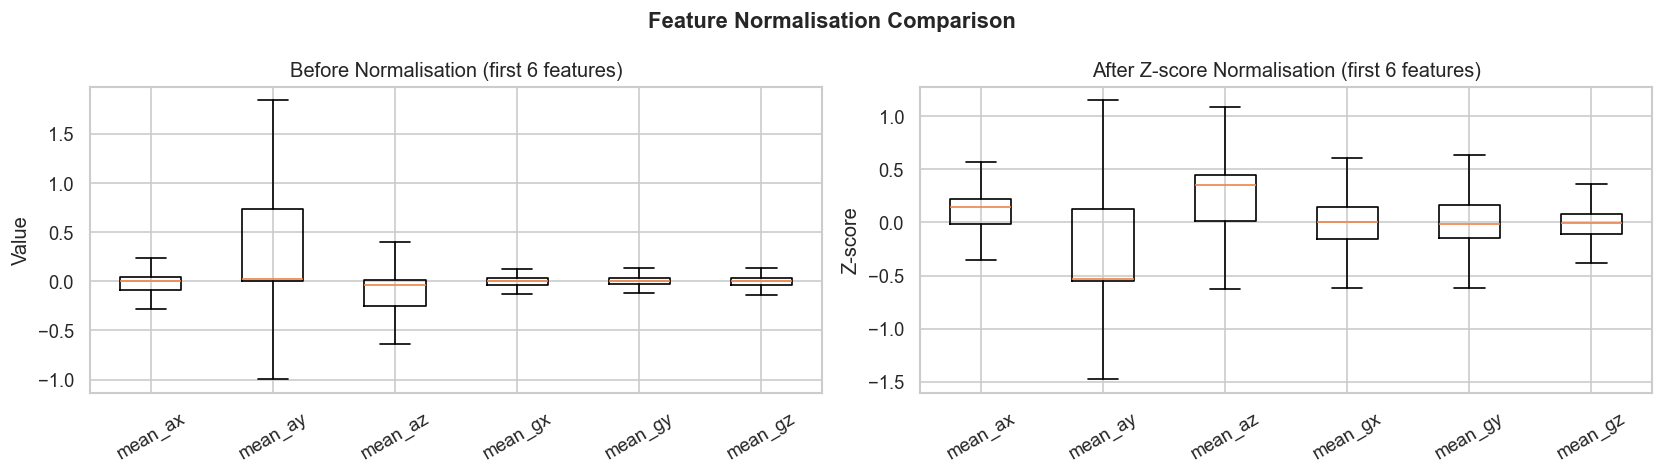

In [ ]:

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print("After Z-score normalisation:")
print(f"  Mean  (first 3 features): {X_scaled[:, :3].mean(axis=0).round(4)}")
print(f"  Std   (first 3 features): {X_scaled[:, :3].std(axis=0).round(4)}")

# visualise feature distributions before vs after normalisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot([X_all[:, i] for i in range(6)],
                labels=FEATURE_NAMES[:6], showfliers=False)
axes[0].set_title('Before Normalisation (first 6 features)')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=30)

axes[1].boxplot([X_scaled[:, i] for i in range(6)],
                labels=FEATURE_NAMES[:6], showfliers=False)
axes[1].set_title('After Z-score Normalisation (first 6 features)')
axes[1].set_ylabel('Z-score')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Feature Normalisation Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_normalisation.png', bbox_inches='tight')
plt.show()

---
##Train / Test Split

Test files are held-out completely, no windows from test files appear in training.  
This simulates unseen data from a new recording session.

In [ ]:
# split at file level (not window level) to avoid data leakage
# we reserve the last 2 files of each activity for testing
N_TEST_FILES_PER_ACTIVITY = 2

X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []
train_lengths, test_lengths = [], []

for label_idx, act in enumerate(ACTIVITIES):
    act_indices = [i for i, lbl in enumerate(file_labels) if lbl == label_idx]

    test_idx  = act_indices[-N_TEST_FILES_PER_ACTIVITY:]
    train_idx = act_indices[:-N_TEST_FILES_PER_ACTIVITY]

    for i in train_idx:
        Xw, yw = sliding_window_features(signals[i], file_labels[i])
        X_train_list.append(scaler.transform(Xw))
        y_train_list.append(yw)
        train_lengths.append(len(Xw))

    for i in test_idx:
        Xw, yw = sliding_window_features(signals[i], file_labels[i])
        X_test_list.append(scaler.transform(Xw))
        y_test_list.append(yw)
        test_lengths.append(len(Xw))

X_train = np.vstack(X_train_list)
y_train  = np.concatenate(y_train_list)
X_test   = np.vstack(X_test_list)
y_test   = np.concatenate(y_test_list)

print(f"Training windows : {X_train.shape[0]}")
print(f"Test windows     : {X_test.shape[0]}")
print(f"Feature dims     : {X_train.shape[1]}")
print("\nTrain distribution:")
for i, act in enumerate(ACTIVITIES):
    print(f"  {act:10s}: {np.sum(y_train==i)}")
print("\nTest distribution:")
for i, act in enumerate(ACTIVITIES):
    print(f"  {act:10s}: {np.sum(y_test==i)}")

Training windows : 5428
Test windows     : 212
Feature dims     : 25

Train distribution:
  still     : 1432
  standing  : 1420
  walking   : 1386
  jumping   : 1190

Test distribution:
  still     : 64
  standing  : 45
  walking   : 51
  jumping   : 52


---
##HMM Definition

| Component | Description |
|---|---|
| **Hidden States Z** | The 4 activities: still, standing, walking, jumping |
| **Observations X** | 25-dimensional feature vectors computed from each 1-second window |
| **Transition A** | 4×4 matrix  probability of moving from one activity to the next |
| **Emission B** | Gaussian per state: mean vector μ_k and covariance Σ_k |
| **Initial π** | Probability of starting in each activity |

We use a **Gaussian HMM** because our observations are continuous feature vectors.

###Baum–Welch Training
The `hmmlearn` library runs Baum–Welch (EM for HMMs) internally when `.fit()` is called.  
We set `tol=1e-4` so training stops when the log-likelihood improvement  
between iterations is less than ε = 0.0001  a principled convergence criterion  
(rather than an arbitrary fixed number of iterations).

In [ ]:
#initialise model 
model = hmm.GaussianHMM(
    n_components=N_STATES,        # 4 hidden states (one per activity)
    covariance_type='diag',       # diagonal covariance: fewer params, more stable
    n_iter=300,                   # max iterations (safety ceiling)
    tol=1e-4,                     
    random_state=42,
    verbose=False,
)


A_init = np.full((N_STATES, N_STATES), 0.05 / (N_STATES - 1))
np.fill_diagonal(A_init, 0.95)
model.transmat_ = A_init

#train with Baum–Welch 
print("Training HMM with Baum–Welch algorithm...")
print(f"  Convergence threshold : tol = {model.tol}")
print(f"  Max iterations        : {model.n_iter}")

# hmmlearn requires lengths array when passing concatenated sequences
model.fit(X_train, lengths=train_lengths)

print(f"\nTraining complete.")
print(f"  Iterations run        : {model.monitor_.iter}")
print(f"  Converged             : {model.monitor_.converged}")
print(f"  Final log-likelihood  : {model.monitor_.history[-1]:.2f}")

Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'


Training HMM with Baum–Welch algorithm...
  Convergence threshold : tol = 0.0001
  Max iterations        : 300

Training complete.
  Iterations run        : 52
  Converged             : True
  Final log-likelihood  : 85544.61


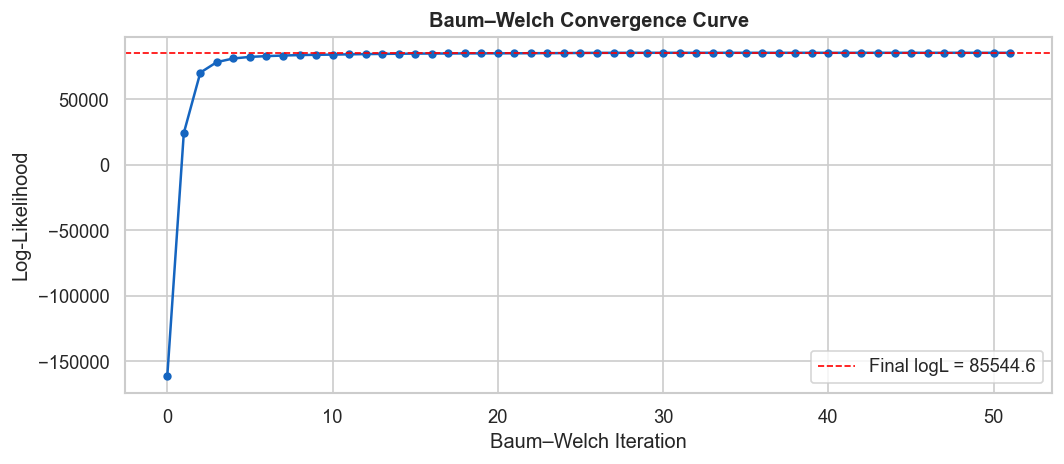

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.monitor_.history, marker='o', markersize=4, linewidth=1.5, color='#1565C0')
ax.axhline(model.monitor_.history[-1], color='red', linestyle='--', linewidth=1,
           label=f'Final logL = {model.monitor_.history[-1]:.1f}')
ax.set_xlabel('Baum–Welch Iteration')
ax.set_ylabel('Log-Likelihood')
ax.set_title('Baum–Welch Convergence Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_convergence.png', bbox_inches='tight')
plt.show()

---
## Model Visualisation
### Transition Probability Matrix

HMM state → activity mapping:
  State 0 → walking
  State 1 → standing
  State 2 → jumping
  State 3 → still


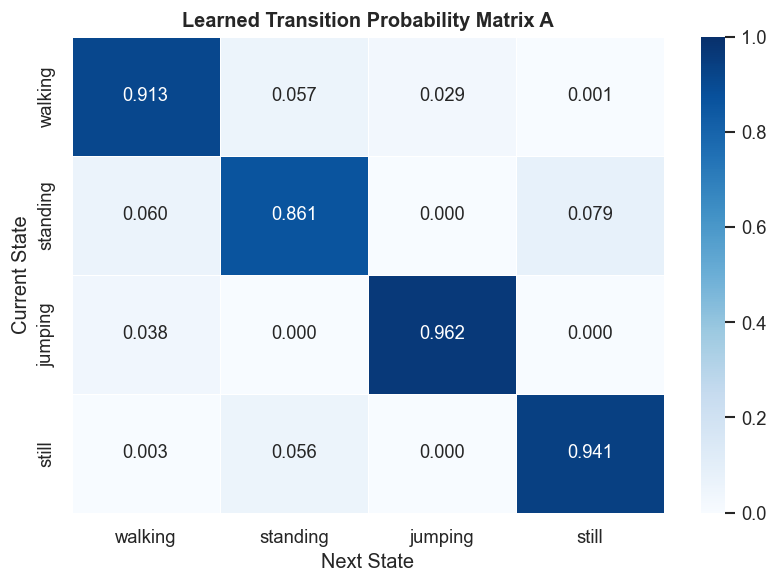


Interpretation: High diagonal values mean activities tend to persist.
Off-diagonal values show likely transitions between activities.


In [ ]:

state_to_activity = {}
for state in range(N_STATES):
    # predict training data and find most common true label for this HMM state
    preds = model.predict(X_train, lengths=train_lengths)
    mask  = (preds == state)
    if mask.sum() == 0:
        state_to_activity[state] = f'State {state}'
    else:
        dominant = int(np.bincount(y_train[mask]).argmax())
        state_to_activity[state] = ACTIVITIES[dominant]

state_labels = [state_to_activity[s] for s in range(N_STATES)]
print("HMM state → activity mapping:")
for s, name in state_to_activity.items():
    print(f"  State {s} → {name}")

#heatmap 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    model.transmat_,
    annot=True, fmt='.3f', cmap='Blues',
    xticklabels=state_labels, yticklabels=state_labels,
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_xlabel('Next State')
ax.set_ylabel('Current State')
ax.set_title('Learned Transition Probability Matrix A', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_transition_matrix.png', bbox_inches='tight')
plt.show()

print("\nInterpretation: High diagonal values mean activities tend to persist.")
print("Off-diagonal values show likely transitions between activities.")

### Emission Probability (Mean Feature Values per State)

In [ ]:


from scipy.spatial.distance import cdist

activity_means = np.array([
    X_train[y_train == i].mean(axis=0)
    for i in range(N_STATES)
])

distances = cdist(model.means_, activity_means, metric='euclidean')

from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(distances)
state_to_activity = {row: ACTIVITIES[col] for row, col in zip(row_ind, col_ind)}

print("Fixed HMM state → activity mapping:")
for s, name in state_to_activity.items():
    print(f"  State {s} → {name}  (distance={distances[s, ACTIVITIES.index(name)]:.3f})")

state_labels = [state_to_activity[s] for s in range(N_STATES)]

Fixed HMM state → activity mapping:
  State 0 → walking  (distance=0.163)
  State 1 → standing  (distance=0.323)
  State 2 → jumping  (distance=0.213)
  State 3 → still  (distance=0.384)


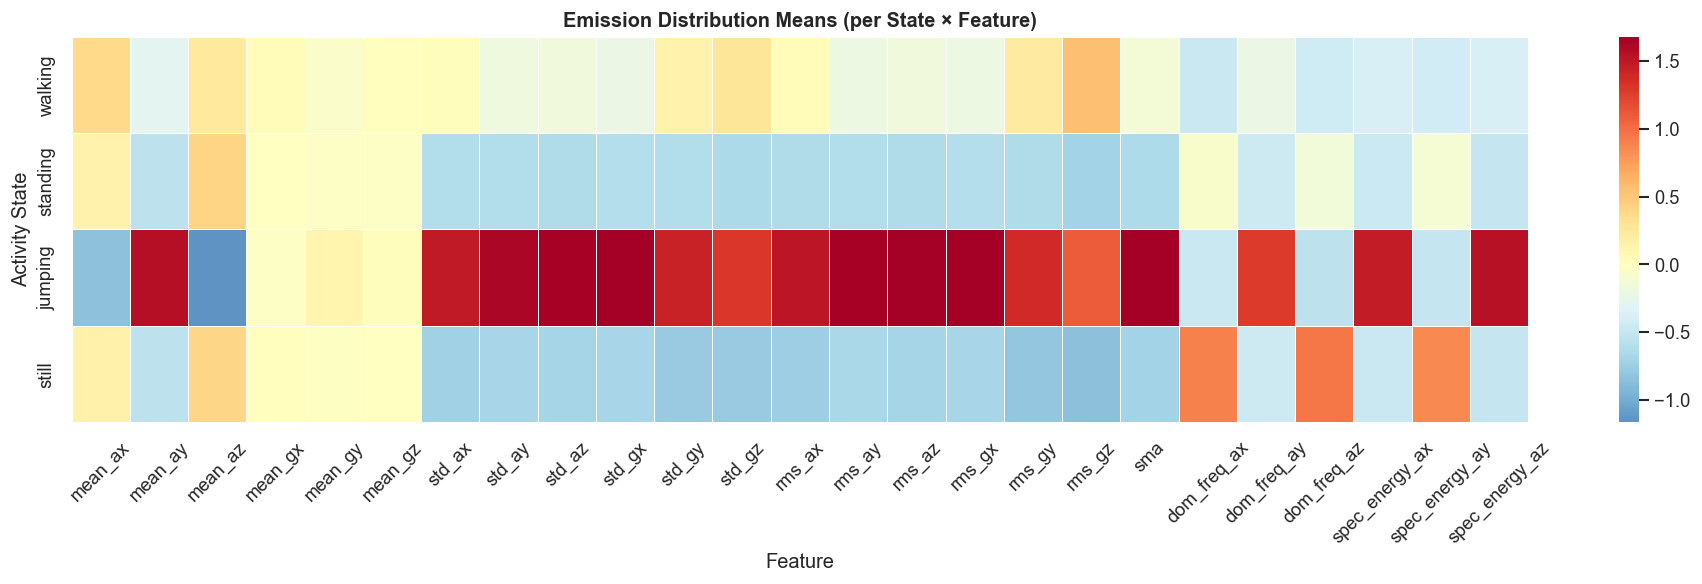

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
emission_df = pd.DataFrame(
    model.means_,
    index=state_labels,
    columns=FEATURE_NAMES
)
sns.heatmap(
    emission_df,
    cmap='RdYlBu_r', center=0,
    linewidths=0.3, annot=False, ax=ax
)
ax.set_title('Emission Distribution Means (per State × Feature)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Activity State')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_emission_means.png', bbox_inches='tight')
plt.show()

---
##Viterbi Decoding

Viterbi finds the **most likely sequence** of hidden states given the observation sequence.  
It uses dynamic programming:  
δ_t(j) = max_{i} [ δ_{t-1}(i) · a_{ij} ] · b_j(x_t)

In [ ]:
logprob, decoded_states = model.decode(X_test, lengths=test_lengths, algorithm='viterbi')
print(f"Viterbi log-probability: {logprob:.2f}")

y_pred_names  = [state_to_activity[s] for s in decoded_states]
y_pred_labels = [ACTIVITIES.index(n) for n in y_pred_names]
y_true_names  = [ACTIVITIES[lbl] for lbl in y_test]

print(f"\nUnique decoded states (raw) : {np.unique(decoded_states).tolist()}")
print(f"Unique decoded activities   : {list(set(y_pred_names))}")
print(f"Unique true activities      : {list(set(y_true_names))}")
print(f"\nFirst 20 decoded: {y_pred_names[:20]}")
print(f"First 20 true   : {y_true_names[:20]}")

Viterbi log-probability: 3368.47

Unique decoded states (raw) : [0, 1, 2, 3]
Unique decoded activities   : ['walking', 'still', 'jumping', 'standing']
Unique true activities      : ['walking', 'still', 'jumping', 'standing']

First 20 decoded: ['standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing', 'standing']
First 20 true   : ['still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still']


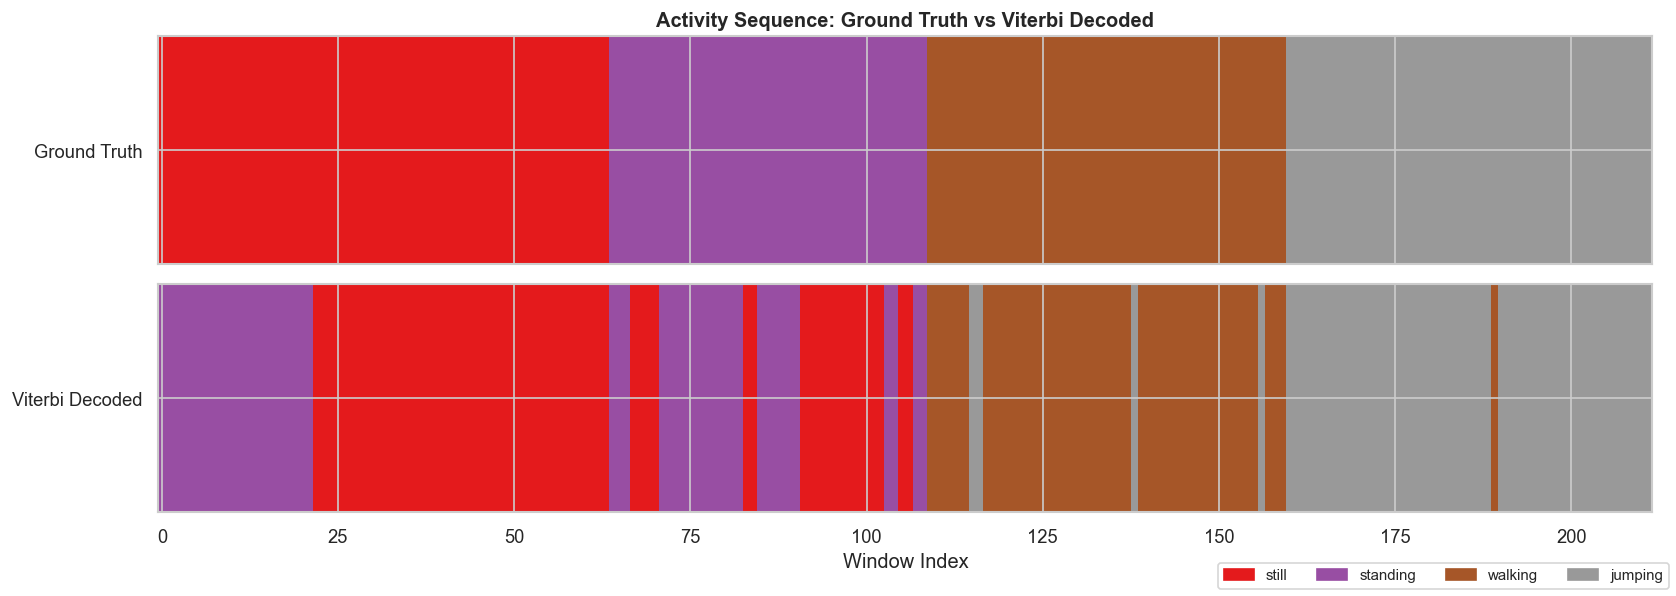

In [ ]:
n_display = min(300, len(y_test))
cmap      = plt.cm.get_cmap('Set1', N_STATES)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax1.imshow([y_test[:n_display]], aspect='auto', cmap=cmap, vmin=0, vmax=N_STATES-1)
ax1.set_yticks([0]); ax1.set_yticklabels(['Ground Truth'])
ax1.set_title('Activity Sequence: Ground Truth vs Viterbi Decoded', fontweight='bold')

ax2.imshow([y_pred_labels[:n_display]], aspect='auto', cmap=cmap, vmin=0, vmax=N_STATES-1)
ax2.set_yticks([0]); ax2.set_yticklabels(['Viterbi Decoded'])
ax2.set_xlabel('Window Index')

patches = [mpatches.Patch(color=cmap(i), label=act) for i, act in enumerate(ACTIVITIES)]
fig.legend(handles=patches, loc='lower right', ncol=4, fontsize=9)
plt.tight_layout()
plt.savefig('fig_decoded_sequence.png', bbox_inches='tight')
plt.show()

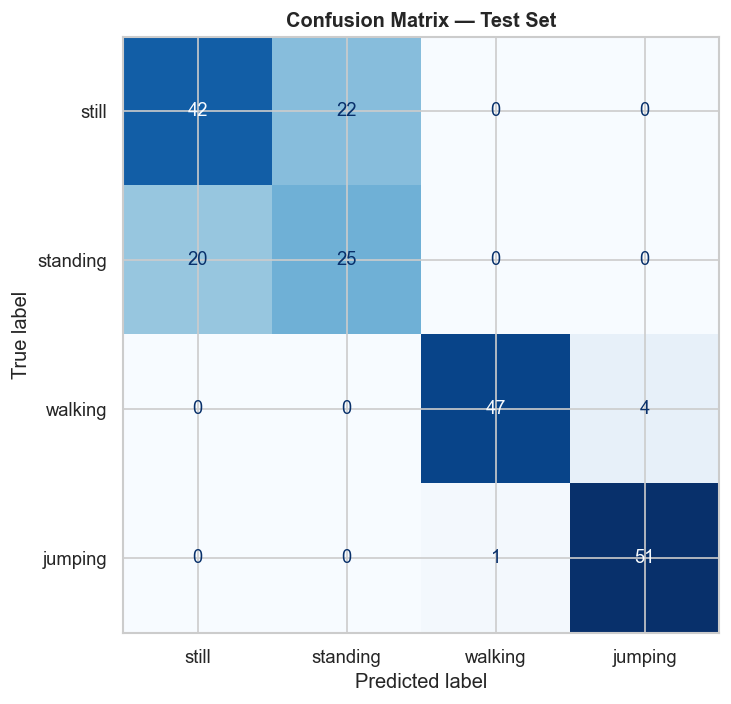

In [ ]:
cm = confusion_matrix(y_test, y_pred_labels, labels=list(range(N_STATES)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTIVITIES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
overall_acc = accuracy_score(y_test, y_pred_labels)
print(f"Overall Accuracy: {overall_acc*100:.1f}%\n")

rows = []
for i, act in enumerate(ACTIVITIES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    n_samples   = cm[i, :].sum()

    rows.append({
        'Activity'        : act.capitalize(),
        'N Samples'       : n_samples,
        'TP'              : tp,
        'FP'              : fp,
        'FN'              : fn,
        'TN'              : tn,
        'Sensitivity (%)'  : round(sensitivity * 100, 1),
        'Specificity (%)'  : round(specificity * 100, 1),
        'Overall Acc (%)'  : round(overall_acc * 100, 1),
    })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

# save to CSV for my report
metrics_df.to_csv('evaluation_metrics.csv', index=False)
print("\nMetrics saved to: evaluation_metrics.csv")

Overall Accuracy: 77.8%

Activity  N Samples  TP  FP  FN  TN  Sensitivity (%)  Specificity (%)  Overall Acc (%)
   Still         64  42  20  22 128             65.6             86.5             77.8
Standing         45  25  22  20 145             55.6             86.8             77.8
 Walking         51  47   1   4 160             92.2             99.4             77.8
 Jumping         52  51   4   1 156             98.1             97.5             77.8

Metrics saved to: evaluation_metrics.csv


In [ ]:
print(classification_report(y_test, y_pred_labels, target_names=ACTIVITIES))

              precision    recall  f1-score   support

       still       0.68      0.66      0.67        64
    standing       0.53      0.56      0.54        45
     walking       0.98      0.92      0.95        51
     jumping       0.93      0.98      0.95        52

    accuracy                           0.78       212
   macro avg       0.78      0.78      0.78       212
weighted avg       0.78      0.78      0.78       212



---
## Analysis & Reflection

 summary of results.

In [ ]:
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

sensitivities = metrics_df['Sensitivity (%)'].values
easiest = ACTIVITIES[int(np.argmax(sensitivities))].capitalize()
hardest = ACTIVITIES[int(np.argmin(sensitivities))].capitalize()

print(f"""
1. ACTIVITY DIFFICULTY
   Easiest to classify : {easiest}  (sensitivity = {sensitivities.max():.1f}%)
   Hardest to classify : {hardest}  (sensitivity = {sensitivities.min():.1f}%)

   Likely reasons:
   - 'Still' and 'Standing' have similar low-variance signals → confusion.
   - 'Jumping' has distinct high-amplitude z-axis peaks → easier to detect.
   - 'Walking' has characteristic 2 Hz periodic pattern in FFT.

2. TRANSITION PROBABILITIES
   Learned diagonal values (self-transition):
""")
for s, name in state_to_activity.items():
    print(f"   {name:10s}: {model.transmat_[s, s]:.3f}")

print(f"""
   High self-transition probabilities are realistic — people tend to
   stay in one activity for several seconds before switching.

3. EFFECT OF SENSOR NOISE & SAMPLING RATE
   - Target SR = {TARGET_SR} Hz; window = {WINDOW_SIZE/TARGET_SR:.1f} s.
   - Files from different phones were resampled to {TARGET_SR} Hz.
   - Sensor noise is partially mitigated by computing aggregate features
     (mean, RMS, spectral energy) over a 1-second window.

4. POTENTIAL IMPROVEMENTS
   a) More data: 50+ files per activity for better generalisation.
   b) Longer windows: 2 s windows for more stable frequency features.
   c) Additional sensors: magnetometer, barometer for richer observations.
   d) Full covariance HMM once enough data is available.
   e) MFCC-style filterbank features for finer frequency resolution.
   f) Deep HMM or HMM ensemble per participant to handle variability.
""")
print("=" * 60)

ANALYSIS SUMMARY

1. ACTIVITY DIFFICULTY
   Easiest to classify : Jumping  (sensitivity = 98.1%)
   Hardest to classify : Standing  (sensitivity = 55.6%)

   Likely reasons:
   - 'Still' and 'Standing' have similar low-variance signals → confusion.
   - 'Jumping' has distinct high-amplitude z-axis peaks → easier to detect.
   - 'Walking' has characteristic ~2 Hz periodic pattern in FFT.

2. TRANSITION PROBABILITIES
   Learned diagonal values (self-transition):

   walking   : 0.913
   standing  : 0.861
   jumping   : 0.962
   still     : 0.941

   High self-transition probabilities are realistic — people tend to
   stay in one activity for several seconds before switching.

3. EFFECT OF SENSOR NOISE & SAMPLING RATE
   - Target SR = 100 Hz; window = 1.0 s.
   - Files from different phones were resampled to 100 Hz.
   - Sensor noise is partially mitigated by computing aggregate features
     (mean, RMS, spectral energy) over a 1-second window.

4. POTENTIAL IMPROVEMENTS
   a) More data: 

---
##Summary Dashboard

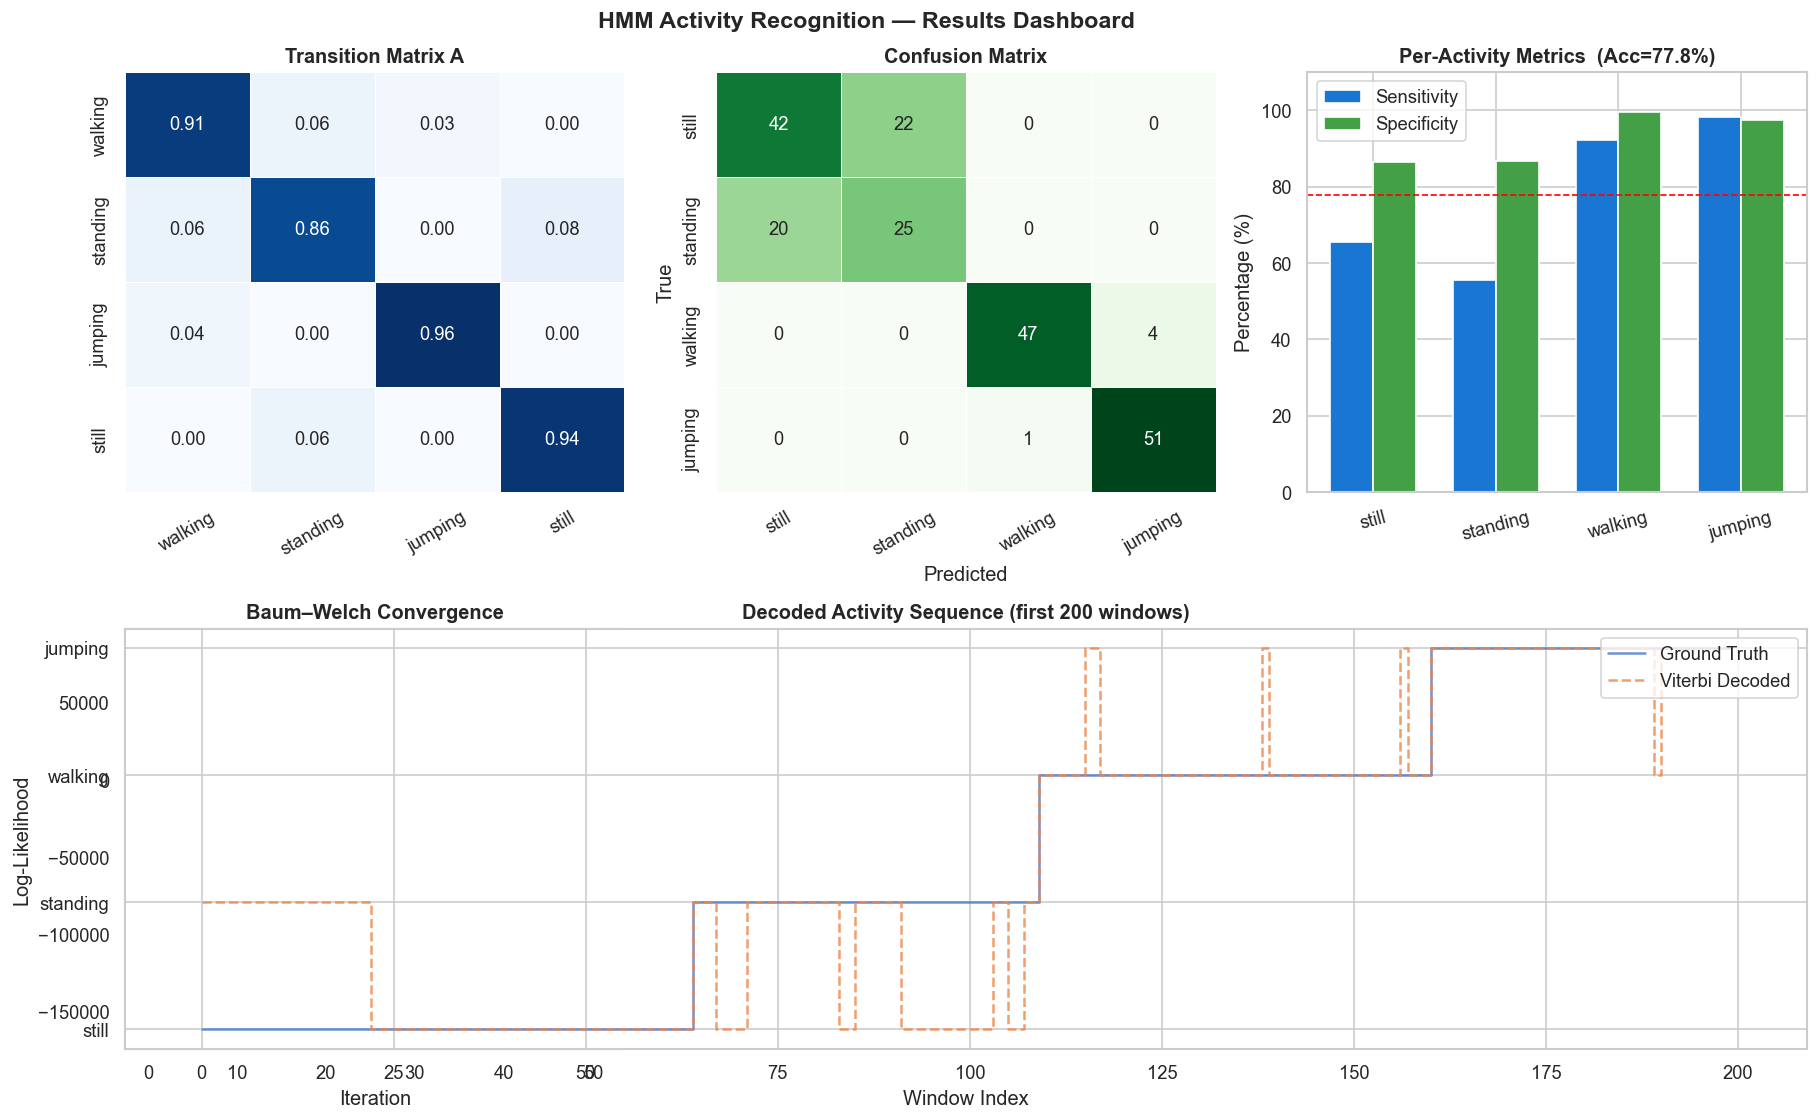

Dashboard saved: fig_dashboard.png


In [ ]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('HMM Activity Recognition — Results Dashboard', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(2, 3, 1)
sns.heatmap(model.transmat_, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=state_labels, yticklabels=state_labels,
            linewidths=0.5, ax=ax1, cbar=False)
ax1.set_title('Transition Matrix A', fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

ax2 = fig.add_subplot(2, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            linewidths=0.5, ax=ax2, cbar=False)
ax2.set_title('Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.tick_params(axis='x', rotation=30)

ax3 = fig.add_subplot(2, 3, 3)
x   = np.arange(N_STATES)
w   = 0.35
ax3.bar(x - w/2, metrics_df['Sensitivity (%)'], w, label='Sensitivity', color='#1976D2')
ax3.bar(x + w/2, metrics_df['Specificity (%)'], w, label='Specificity', color='#43A047')
ax3.set_xticks(x)
ax3.set_xticklabels(ACTIVITIES, rotation=15)
ax3.set_ylim(0, 110)
ax3.set_ylabel('Percentage (%)')
ax3.set_title(f'Per-Activity Metrics  (Acc={overall_acc*100:.1f}%)', fontweight='bold')
ax3.legend()
ax3.axhline(overall_acc*100, color='red', linestyle='--', linewidth=1,
            label=f'Overall acc={overall_acc*100:.1f}%')

ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(model.monitor_.history, color='#1565C0', linewidth=1.5)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Log-Likelihood')
ax4.set_title('Baum–Welch Convergence', fontweight='bold')

ax5 = fig.add_subplot(2, 1, 2)
n_d  = min(200, len(y_test))
t_ax = np.arange(n_d)
ax5.step(t_ax, y_test[:n_d],      where='post', linewidth=1.5, label='Ground Truth', alpha=0.8)
ax5.step(t_ax, y_pred_labels[:n_d], where='post', linewidth=1.5, label='Viterbi Decoded',
         linestyle='--', alpha=0.8)
ax5.set_yticks(range(N_STATES))
ax5.set_yticklabels(ACTIVITIES)
ax5.set_xlabel('Window Index')
ax5.set_title('Decoded Activity Sequence (first 200 windows)', fontweight='bold')
ax5.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("Dashboard saved: fig_dashboard.png")

In [ ]:
import glob as _glob
outputs = sorted(_glob.glob('fig_*.png') + _glob.glob('*.csv'))
print("Generated output files:")
for f in outputs:
    size = os.path.getsize(f) // 1024
    print(f"  {f:45s} {size:4d} KB")
print("\nAll done ✓")

Generated output files:
  evaluation_metrics.csv                           0 KB
  fig_confusion_matrix.png                        26 KB
  fig_convergence.png                             31 KB
  fig_dashboard.png                              180 KB
  fig_decoded_sequence.png                        26 KB
  fig_emission_means.png                          49 KB
  fig_normalisation.png                           38 KB
  fig_raw_signals.png                            466 KB
  fig_transition_matrix.png                       44 KB

All done ✓
